# Target Distribution

y_HY3 shape: (909, 1)
y_HY4_3 shape: (909, 1)


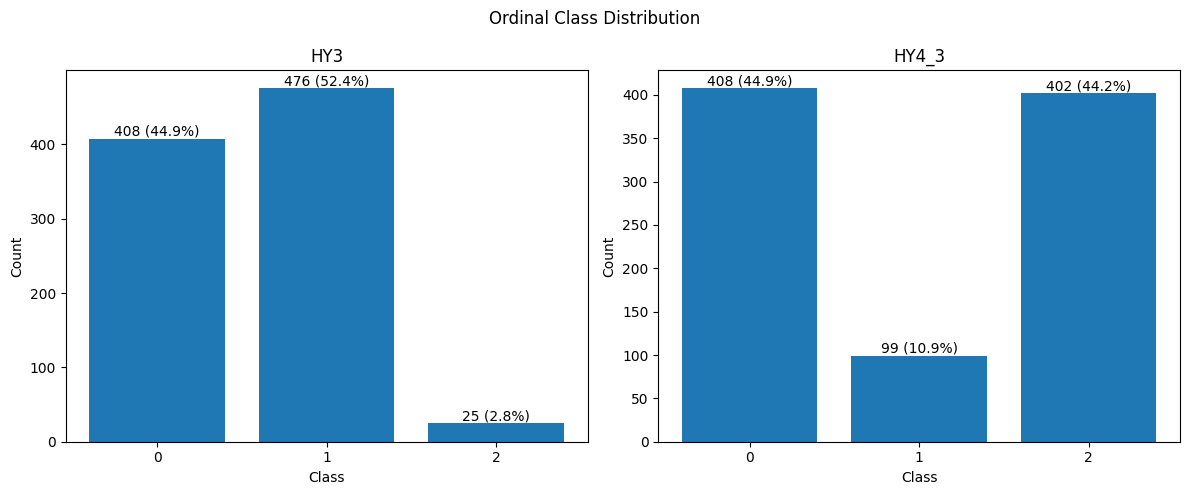

In [1]:
import pandas as pd
import json
import numpy as np
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[3]

import matplotlib.pyplot as plt


y_HY3 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv", index_col=0)
y_HY43 = pd.read_csv(project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv", index_col=0)
print("y_HY3 shape:", y_HY3.shape)
print("y_HY4_3 shape:", y_HY43.shape)


datasets = {
    "HY3": y_HY3,
    'HY4_3': y_HY43,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, df) in zip(axes, datasets.items()):
    
    counts = df.iloc[:,0].value_counts().sort_index()
    percentages = counts / counts.sum() * 100
    
    bars = ax.bar(counts.index.astype(str), counts.values)
    
    # añadir texto con conteo y porcentaje
    for i, (count, pct) in enumerate(zip(counts.values, percentages.values)):
        ax.text(i, count, f"{count} ({pct:.1f}%)", 
                ha='center', va='bottom')
    
    ax.set_title(name)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")

plt.suptitle("Ordinal Class Distribution")
plt.tight_layout()
plt.show()

# Files

In [2]:
import os
import re

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/Domain_data.json", "r") as archivo:
    full_domain = json.load(archivo)

with open(project_root/"SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/UPDRS_Domain_data.json", "r") as archivo:
    updrs_domain = json.load(archivo)

X_multiples= { 'X_STATS':project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_STATS.csv', 
                    'X_V06_STATS': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+STATS.csv',
                      'X_V06_DELTA': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/X_V06+Deltas.csv'}

y_multiples = { 'HY3': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY3.csv',
                'HY43': project_root/'SCRIPTS/PYTHON/MODEL_ANALYSIS/DATA/HY_SCALE/FULL_FEATURES/y_HY43.csv',
        
                }




output_path= project_root / "SCRIPTS/PYTHON/MODEL_ANALYSIS/Performance_Results/Multiclass/"

dominios_full = {
    'X_STATS': { 
        'motor': full_domain['SC_data'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['NM_data_STATS']
    },

    'X_V06_STATS': {
        'motor': full_domain['SC_data'] +full_domain['M_data_V06'] + full_domain['M_data_STATS'],
        'non_motor': full_domain['SC_data'] + full_domain['NM_data_V06'] + full_domain['NM_data_STATS']
    },

    'X_V06_DELTA': {
        'motor': full_domain['SC_data'] + full_domain['M_data_V06'] + full_domain['M_data_DELTA'],
        'non_motor': full_domain['NM_data_V06'] + full_domain['NM_data_DELTA']
    }
}

dominios_updrs = {
    'X_STATS': {

        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_STATS': {
        
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_STATS'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_STATS'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_STATS']
    },

    'X_V06_DELTA': {
        'examen_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_MOTOR_V06'] + updrs_domain['UPDRS_MOTOR_delta'],
        'impacto_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_IMPACTO_MOTOR_V06'] + updrs_domain['UPDRS_IMPACTO_MOTOR_delta'],
        'non_motor': updrs_domain['SC_data'] + updrs_domain['UPDRS_NO_MOTOR_V06'] + updrs_domain['UPDRS_NO_MOTOR_delta']
    }
}

cols_updrs_full={}
for val in dominios_updrs:
    cols_updrs_val=[]
    for val_sub in dominios_updrs[val]:
        print(f"Evaluating domain: {val} - {val_sub}")
        cols_updrs_val+=dominios_updrs[val][val_sub]
    cols_updrs_full[val]=cols_updrs_val

cols_updrs_full['X_V06_STATS']=list(set(cols_updrs_full['X_V06_STATS']))
cols_updrs_full['X_STATS']=list(set(cols_updrs_full['X_STATS']))
cols_updrs_full['X_V06_DELTA']=list(set(cols_updrs_full['X_V06_DELTA']))


Evaluating domain: X_STATS - examen_motor
Evaluating domain: X_STATS - impacto_motor
Evaluating domain: X_STATS - non_motor
Evaluating domain: X_V06_STATS - examen_motor
Evaluating domain: X_V06_STATS - impacto_motor
Evaluating domain: X_V06_STATS - non_motor
Evaluating domain: X_V06_DELTA - examen_motor
Evaluating domain: X_V06_DELTA - impacto_motor
Evaluating domain: X_V06_DELTA - non_motor


# Models Pairs (0 vs 12) and (01 vs 2)

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from imblearn.pipeline import Pipeline


classification_models_WB = {

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight = 'balanced'
    ),

    "random_forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight = 'balanced'
    ),

    "xgboost": XGBClassifier(
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42
       
    ),

    "adaboost": AdaBoostClassifier(
        algorithm="SAMME", 
        random_state=42
    ),

    "svm": SVC(
        kernel="rbf",
        probability=True,  
        random_state=42,
        class_weight = 'balanced'
    ),

    "logistic_regression": LogisticRegression(
        random_state=42,
        n_jobs=-1,
        max_iter=10000,
        class_weight = 'balanced'
    ),

    "knn": KNeighborsClassifier(
        n_jobs=-1
    ),

    "gaussian_nb": GaussianNB()
}

classification_models_WB = {
    name: Pipeline([
        ("model", model)])
    for name, model in classification_models_WB.items()
}

# Performance Functions

## Normal

In [4]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)


def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    # =========================
    # GLOBAL METRICS
    # =========================
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    # =========================
    # COST MATRIX
    # =========================
    # Formato:
    # cost_matrix[true_class, predicted_class]
    #
    # Por defecto:
    #   TN = 0
    #   FP = 1
    #   FN = 5
    #   TP = 0
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    # =========================
    # AUC
    # =========================
    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    # =========================
    # PER-CLASS METRICS
    # =========================
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # =========================
    # CONFUSION-MATRIX METRICS
    # =========================
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


def _build_row_binary(results, model_name):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "target_type": "binary",
        "classes": [0, 1],
        "n_classes": 2,
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1)

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1)

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1)

    return row


def evaluate_model_10x10_metrics_binary(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    positive_label=1,
    cost_matrix=None,
):
    # =========================
    # CONVERT TO NUMPY
    # =========================
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    if len(unique_classes) != 2:
        raise ValueError(
            f"El target y debe ser binario. Clases encontradas: {unique_classes}"
        )

    # Opcional: normalizar etiquetas a {0, 1}
    # Si ya vienen como 0 y 1, no cambia nada.
    if not np.array_equal(np.sort(unique_classes), np.array([0, 1])):
        mapping = {unique_classes[0]: 0, unique_classes[1]: 1}
        y_arr = np.vectorize(mapping.get)(y_arr)
        positive_label = 1

    all_rows = []

    # =========================
    # LOOP MODELS
    # =========================
    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        # =========================
        # OUTER LOOP
        # =========================
        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                y_pred_val = est.predict(X_val_inner)

                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                inner_scores.append(
                    _compute_metrics_binary(
                        y_true=y_val_inner,
                        y_pred=y_pred_val,
                        y_proba=y_proba_val,
                        positive_label=positive_label,
                        cost_matrix=cost_matrix
                    )
                )

            cv_mean_scores = _mean_metrics(inner_scores)

            # =========================
            # FINAL MODEL (OUTER TRAIN + OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            # TRAIN METRICS
            y_pred_train = final_model.predict(X_train_outer)

            y_proba_train = (
                final_model.predict_proba(X_train_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            train_scores = _compute_metrics_binary(
                y_true=y_train_outer,
                y_pred=y_pred_train,
                y_proba=y_proba_train,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            # TEST METRICS
            y_pred_test = final_model.predict(X_test_outer)

            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_binary(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                positive_label=positive_label,
                cost_matrix=cost_matrix
            )

            results.append({
                "cv": cv_mean_scores,
                "train": train_scores,
                "test": test_scores
            })

        # =========================
        # SAVE RESULT ROW
        # =========================
        row = _build_row_binary(
                results=results,
                model_name=model_name,
            )
        all_rows.append(row)
        print(
                f"{model_name} | "
                f"AUC CV={row['auc_cv_mean']:.4f} | "
                f"AUC Train={row['auc_train_mean']:.4f} | "
                f"AUC Test={row['auc_test_mean']:.4f}"
            )

    return pd.DataFrame(all_rows)

## LDA 

In [5]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    precision_recall_fscore_support,
    confusion_matrix,
)
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


# =========================================================
# METRICS
# =========================================================
def _compute_metrics_binary(
    y_true,
    y_pred,
    y_proba=None,
    positive_label=1,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int).ravel()
    y_pred = np.asarray(y_pred, dtype=int).ravel()

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1"] = f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["recall"] = recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0)
    metrics["precision"] = precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0)

    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1],
            [5, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_cost_mean"] = sample_costs.mean()
    metrics["misclassification_cost_total"] = sample_costs.sum()
    metrics["misclassification_score"] = -sample_costs.mean()

    for cls in [0, 1]:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_cost_mean_true_class_{cls}"] = np.nan

    if y_proba is not None:
        try:
            y_proba = np.asarray(y_proba)

            if y_proba.ndim == 1:
                pos_scores = y_proba
            elif y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                pos_scores = y_proba[:, 1]
            else:
                pos_scores = None

            metrics["auc"] = roc_auc_score(y_true, pos_scores) if pos_scores is not None else np.nan
        except Exception:
            metrics["auc"] = np.nan
    else:
        metrics["auc"] = np.nan

    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0
    )

    for i, cls in enumerate([0, 1]):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics["tn"] = tn
    metrics["fp"] = fp
    metrics["fn"] = fn
    metrics["tp"] = tp

    metrics["specificity"] = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    metrics["npv"] = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    metrics["fpr"] = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    metrics["fnr"] = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.mean([m[k] for m in metrics_list]) for k in keys}


# =========================================================
# TASK DEFINITIONS
# =========================================================
def _get_task_definitions():
    return [
        {
            "task_name": "0 vs 1-2",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [1, 2],
            "negative_group": [0],
            "positive_label_original": [1, 2],
        },
        {
            "task_name": "0-1 vs 2",
            "task_type": "grouped_multiclass_lda",
            "classes_used": [0, 1, 2],
            "positive_group": [0, 1],
            "negative_group": [2],
            "positive_label_original": [0, 1],
        },
    ]


# =========================================================
# TARGET / DATA HELPERS
# =========================================================
def _recode_grouped_target(y, positive_group):
    y = np.asarray(y).ravel()
    return np.isin(y, positive_group).astype(int)


def _safe_fit_lda(X_train, y_train, n_components):
    y_train = np.asarray(y_train).ravel()
    n_classes = len(np.unique(y_train))
    n_features = X_train.shape[1]

    max_components = min(n_classes - 1, n_features)

    if max_components < 1:
        raise ValueError(
            f"No se puede ajustar LDA: n_classes={n_classes}, n_features={n_features}"
        )

    lda = LinearDiscriminantAnalysis(
        n_components=min(n_components, max_components)
    )
    lda.fit(X_train, y_train)
    return lda


def _get_scores_for_auc(estimator, X):
    if hasattr(estimator, "predict_proba"):
        try:
            return estimator.predict_proba(X)
        except Exception:
            pass

    if hasattr(estimator, "decision_function"):
        try:
            return estimator.decision_function(X)
        except Exception:
            pass

    return None


def _build_row_task(results, model_name, task_info):
    metric_names = list(results[0]["cv"].keys())

    row = {
        "model": model_name,
        "task_name": task_info["task_name"],
        "task_type": task_info["task_type"],
        "target_type": "binary_derived_from_multiclass",
        "original_classes": [0, 1, 2],
        "n_original_classes": 3,
        "lda_mode": "multiclass_lda_2d_then_recode",
        "classes_used": task_info["classes_used"],
        "positive_group": task_info["positive_group"],
        "negative_group": task_info["negative_group"],
    }

    for metric in metric_names:
        cv_vals = [r["cv"][metric] for r in results]
        train_vals = [r["train"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_cv_mean"] = np.mean(cv_vals)
        row[f"{metric}_cv_std"] = np.std(cv_vals, ddof=1) if len(cv_vals) > 1 else 0.0

        row[f"{metric}_train_mean"] = np.mean(train_vals)
        row[f"{metric}_train_std"] = np.std(train_vals, ddof=1) if len(train_vals) > 1 else 0.0

        row[f"{metric}_test_mean"] = np.mean(test_vals)
        row[f"{metric}_test_std"] = np.std(test_vals, ddof=1) if len(test_vals) > 1 else 0.0

    return row


# ====================
# CORE EVALUATION:
# ====================
def _evaluate_grouped_task(
    model,
    X_arr,
    y_arr,
    positive_group,
    n_outer,
    n_inner,
    test_size_outer,
    test_size_inner,
    random_state,
    cost_matrix,
):
    unique_classes = np.unique(y_arr)
    expected = np.array([0, 1, 2])

    if not np.array_equal(np.sort(unique_classes), expected):
        raise ValueError(
            f"Para grouped tasks se esperaban clases [0,1,2]. Encontradas: {unique_classes}"
        )

    outer_cv = StratifiedShuffleSplit(
        n_splits=n_outer,
        test_size=test_size_outer,
        random_state=random_state
    )

    results = []

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_arr, y_arr), start=1):
        X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
        y_train_outer_mc, y_test_outer_mc = y_arr[train_idx], y_arr[test_idx]

        inner_cv = StratifiedShuffleSplit(
            n_splits=n_inner,
            test_size=test_size_inner,
            random_state=random_state + outer_fold
        )

        inner_scores = []

        for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer_mc):
            X_train_inner = X_train_outer[train_inner_idx]
            y_train_inner_mc = y_train_outer_mc[train_inner_idx]
            X_val_inner = X_train_outer[val_inner_idx]
            y_val_inner_mc = y_train_outer_mc[val_inner_idx]

            lda = _safe_fit_lda(X_train_inner, y_train_inner_mc, n_components=2)
            X_train_inner_lda = lda.transform(X_train_inner)
            X_val_inner_lda = lda.transform(X_val_inner)

            y_train_inner_bin = _recode_grouped_target(y_train_inner_mc, positive_group=positive_group)
            y_val_inner_bin = _recode_grouped_target(y_val_inner_mc, positive_group=positive_group)

            est = clone(model)
            est.fit(X_train_inner_lda, y_train_inner_bin)

            y_pred_val = est.predict(X_val_inner_lda)
            y_score_val = _get_scores_for_auc(est, X_val_inner_lda)

            inner_scores.append(
                _compute_metrics_binary(
                    y_true=y_val_inner_bin,
                    y_pred=y_pred_val,
                    y_proba=y_score_val,
                    positive_label=1,
                    cost_matrix=cost_matrix
                )
            )

        cv_mean_scores = _mean_metrics(inner_scores)

        lda_final = _safe_fit_lda(X_train_outer, y_train_outer_mc, n_components=2)
        X_train_outer_lda = lda_final.transform(X_train_outer)
        X_test_outer_lda = lda_final.transform(X_test_outer)

        y_train_outer_bin = _recode_grouped_target(y_train_outer_mc, positive_group=positive_group)
        y_test_outer_bin = _recode_grouped_target(y_test_outer_mc, positive_group=positive_group)

        final_model = clone(model)
        final_model.fit(X_train_outer_lda, y_train_outer_bin)

        y_pred_train = final_model.predict(X_train_outer_lda)
        y_score_train = _get_scores_for_auc(final_model, X_train_outer_lda)

        train_scores = _compute_metrics_binary(
            y_true=y_train_outer_bin,
            y_pred=y_pred_train,
            y_proba=y_score_train,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        y_pred_test = final_model.predict(X_test_outer_lda)
        y_score_test = _get_scores_for_auc(final_model, X_test_outer_lda)

        test_scores = _compute_metrics_binary(
            y_true=y_test_outer_bin,
            y_pred=y_pred_test,
            y_proba=y_score_test,
            positive_label=1,
            cost_matrix=cost_matrix
        )

        results.append({
            "cv": cv_mean_scores,
            "train": train_scores,
            "test": test_scores
        })
        

    return results


# =====================
# MAIN FUNCTION
# =====================
def evaluate_model_10x10_metrics_multiclass_special_lda(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
    cost_matrix=None,
):
    """
    Evalúa modelos sobre 2 tareas derivadas de un target multiclase {0,1,2}:

      - 0_vs_1_2
      - 0_1_vs_2

    Ambas usan:
      - LDA multiclass sobre 0,1,2 (2D)
      - luego recodificación binaria

    Devuelve métricas agregadas de:
      - cv
      - train
      - test

    Retorna:
      pd.DataFrame con una fila por model + task
    """
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = np.asarray(y_arr).ravel().astype(int)

    unique_classes = np.unique(y_arr)
    expected = np.array([0, 1, 2])

    if not np.array_equal(np.sort(unique_classes), expected):
        raise ValueError(
            f"El target y debe contener exactamente las clases [0,1,2]. "
            f"Clases encontradas: {unique_classes}"
        )

    all_rows = []
    task_definitions = _get_task_definitions()

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        for task_info in task_definitions:
            print(f"  Task: {task_info['task_name']}")

            results = _evaluate_grouped_task(
                model=model,
                X_arr=X_arr,
                y_arr=y_arr,
                positive_group=task_info["positive_group"],
                n_outer=n_outer,
                n_inner=n_inner,
                test_size_outer=test_size_outer,
                test_size_inner=test_size_inner,
                random_state=random_state,
                cost_matrix=cost_matrix,
            )

            row = _build_row_task(
                        results=results,
                        model_name=model_name,
                        task_info=task_info
                    )

            all_rows.append(row)

            print(
                f"{model_name} | {task_info['task_name']} | "
                f"AUC CV={row['auc_cv_mean']:.4f} | "
                f"AUC Train={row['auc_train_mean']:.4f} | "
                f"AUC Test={row['auc_test_mean']:.4f}"
            )

    return pd.DataFrame(all_rows)

# Models Performance

In [8]:
# UPDERS DOMAINS
list_results = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)[cols_updrs_full[val]]
    print(f"    Shape in X: {X.shape}")
    for target in ["HY3", "HY43"]:
        print(f"    Evaluating target: {target}")
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)

        print(f"            Shape in X_binary: {X.shape}")
        print(f"            Shape in y_binary: {y.shape}")
   
        df = evaluate_model_10x10_metrics_multiclass_special_lda(
                                                                model_dict=classification_models_WB,
                                                                X=X,
                                                                y=y)
           
        df['X_transfromation'] = 'None_sacler'
        df['Target'] = target
        df['X_Processing'] = val
        list_results.append(df)

final_df_lda = pd.concat(list_results, ignore_index=True)
final_df_lda.to_csv(output_path / "Resultados_multiclass_ordinal_lda.csv", index=False)
final_df_lda

Evaluating domain: X_STATS
    Shape in X: (909, 301)
    Evaluating target: HY3
            Shape in X_binary: (909, 301)
            Shape in y_binary: (909, 1)
Evaluating model: decision_tree
  Task: 0 vs 1-2
decision_tree | 0 vs 1-2 | AUC CV=0.7707 | AUC Train=1.0000 | AUC Test=0.8202
  Task: 0-1 vs 2
decision_tree | 0-1 vs 2 | AUC CV=0.6399 | AUC Train=1.0000 | AUC Test=0.7246
Evaluating model: random_forest
  Task: 0 vs 1-2
random_forest | 0 vs 1-2 | AUC CV=0.8449 | AUC Train=1.0000 | AUC Test=0.9140
  Task: 0-1 vs 2
random_forest | 0-1 vs 2 | AUC CV=0.6570 | AUC Train=1.0000 | AUC Test=0.7410
Evaluating model: extra_trees
  Task: 0 vs 1-2
extra_trees | 0 vs 1-2 | AUC CV=0.8523 | AUC Train=1.0000 | AUC Test=0.9204
  Task: 0-1 vs 2
extra_trees | 0-1 vs 2 | AUC CV=0.7256 | AUC Train=1.0000 | AUC Test=0.7575
Evaluating model: xgboost
  Task: 0 vs 1-2
xgboost | 0 vs 1-2 | AUC CV=0.8369 | AUC Train=1.0000 | AUC Test=0.9110
  Task: 0-1 vs 2
xgboost | 0-1 vs 2 | AUC CV=0.7078 | AUC Trai

In [9]:
final_df_lda

,model,task_name,task_type,target_type,original_classes,n_original_classes,lda_mode,classes_used,positive_group,negative_group,...,fpr_test_std,fnr_cv_mean,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,X_transfromation,Target,X_Processing
0,decision_tree,0 vs 1-2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[1, 2]",[0],...,0.042027,0.257810,0.044413,0.000000,0.000000,0.217333,0.071953,None_sacler,HY3,X_STATS
1,decision_tree,0-1 vs 2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[0, 1]",[2],...,0.180702,0.042151,0.007963,0.000000,0.000000,0.036466,0.013268,None_sacler,HY3,X_STATS
2,random_forest,0 vs 1-2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[1, 2]",[0],...,0.035707,0.232381,0.030344,0.000000,0.000000,0.188667,0.047250,None_sacler,HY3,X_STATS
3,random_forest,0-1 vs 2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[0, 1]",[2],...,0.171031,0.034624,0.012357,0.000000,0.000000,0.022932,0.008014,None_sacler,HY3,X_STATS
4,extra_trees,0 vs 1-2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[1, 2]",[0],...,0.025710,0.231524,0.026702,0.000000,0.000000,0.162667,0.031143,None_sacler,HY3,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,logistic_regression,0-1 vs 2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[0, 1]",[2],...,0.032374,0.156168,0.012818,0.054648,0.009955,0.134868,0.032118,None_sacler,HY43,X_V06_DELTA
104,knn,0 vs 1-2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[1, 2]",[0],...,0.031816,0.163143,0.020018,0.049429,0.010863,0.141060,0.026683,None_sacler,HY43,X_V06_DELTA
105,knn,0-1 vs 2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[0, 1]",[2],...,0.040337,0.131028,0.010121,0.039718,0.011761,0.125000,0.031013,None_sacler,HY43,X_V06_DELTA
106,gaussian_nb,0 vs 1-2,grouped_multiclass_lda,binary_derived_from_multiclass,"[0, 1, 2]",3,multiclass_lda_2d_then_recode,"[0, 1, 2]","[1, 2]",[0],...,0.029541,0.133238,0.017204,0.054857,0.004426,0.121192,0.022086,None_sacler,HY43,X_V06_DELTA


In [ ]:
# UPDERS DOMAINS
list_results = []
for val in dominios_updrs:
    print(f"Evaluating domain: {val}")
    path=X_multiples[val]
    X=pd.read_csv(path, index_col=0)[cols_updrs_full[val]]
    print(f"    Shape in X: {X.shape}")
    for target in ["HY3", "HY43"]:
        print(f"    Evaluating target: {target}")
        path=y_multiples[target]
        y=pd.read_csv(path, index_col=0)
        for pair in ['0 vs 1-2', '0-1 vs 2']: 
            print(f"        Evaluating pair: {pair}")
            y_binary = y.copy()
            
            if pair == '0 vs 1-2':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 1: 1, 2: 1})
                X_binary = X.loc[y_binary.index]
            elif pair == '0-1 vs 2':
                y_binary.iloc[:, 0] = y_binary.iloc[:, 0].replace({0: 0, 1: 0, 2: 1})
                X_binary = X.loc[y_binary.index]
            
            print(f"            Shape in X_binary: {X_binary.shape}")
            print(f"            Shape in y_binary: {y_binary.shape}")
   
            df=evaluate_model_10x10_metrics_binary(model_dict=classification_models_WB, 
                                                    X=X_binary, 
                                                    y=y_binary)
           
            df['X_transfromation'] = 'None_sacler'
            df['Pair'] = pair
            df['Target'] = target
            df['X_Processing'] = val
            list_results.append(df)

final_df = pd.concat(list_results, ignore_index=True)
final_df.to_csv(output_path / "Resultados_multiclass_ordinal.csv", index=False)
final_df

Evaluating domain: X_STATS
    Shape in X: (909, 301)
    Evaluating target: HY3
        Evaluating pair: 0 vs 1-2
            Shape in X_binary: (909, 301)
            Shape in y_binary: (909, 1)
Evaluating model: decision_tree
decision_tree | AUC CV=0.8720 | AUC Train=1.0000 | AUC Test=0.8862
Evaluating model: random_forest
random_forest | AUC CV=0.9673 | AUC Train=1.0000 | AUC Test=0.9779
Evaluating model: extra_trees
extra_trees | AUC CV=0.9682 | AUC Train=1.0000 | AUC Test=0.9780
Evaluating model: xgboost
xgboost | AUC CV=0.9639 | AUC Train=1.0000 | AUC Test=0.9756
Evaluating model: adaboost
adaboost | AUC CV=0.9633 | AUC Train=0.9906 | AUC Test=0.9758
Evaluating model: svm
svm | AUC CV=0.9688 | AUC Train=0.9722 | AUC Test=0.9779
Evaluating model: logistic_regression
logistic_regression | AUC CV=0.9540 | AUC Train=0.9965 | AUC Test=0.9655
Evaluating model: knn
knn | AUC CV=0.9346 | AUC Train=0.9858 | AUC Test=0.9421
Evaluating model: gaussian_nb
gaussian_nb | AUC CV=0.9380 | AUC T

,model,target_type,classes,n_classes,accuracy_cv_mean,accuracy_cv_std,accuracy_train_mean,accuracy_train_std,accuracy_test_mean,accuracy_test_std,...,fnr_cv_mean,fnr_cv_std,fnr_train_mean,fnr_train_std,fnr_test_mean,fnr_test_std,X_transfromation,Pair,Target,X_Processing
0,decision_tree,binary,"[0, 1]",2,0.873246,0.007573,1.000000,0.000000,0.888278,0.028176,...,0.115333,0.008837,0.000000,0.000000,0.092667,0.024835,None_sacler,0 vs 1-2,HY3,X_STATS
1,random_forest,binary,"[0, 1]",2,0.920942,0.006604,1.000000,0.000000,0.934066,0.012087,...,0.094952,0.013197,0.000000,0.000000,0.079333,0.022542,None_sacler,0 vs 1-2,HY3,X_STATS
2,extra_trees,binary,"[0, 1]",2,0.919634,0.007868,1.000000,0.000000,0.933333,0.010332,...,0.090095,0.014837,0.000000,0.000000,0.077333,0.019676,None_sacler,0 vs 1-2,HY3,X_STATS
3,xgboost,binary,"[0, 1]",2,0.911675,0.007474,1.000000,0.000000,0.927473,0.012186,...,0.098857,0.013974,0.000000,0.000000,0.077333,0.020172,None_sacler,0 vs 1-2,HY3,X_STATS
4,adaboost,binary,"[0, 1]",2,0.910262,0.006380,0.940881,0.007851,0.928205,0.011084,...,0.098476,0.012272,0.079202,0.008989,0.080000,0.023727,None_sacler,0 vs 1-2,HY3,X_STATS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,adaboost,binary,"[0, 1]",2,0.857906,0.010521,0.901887,0.007530,0.856777,0.027327,...,0.152976,0.016931,0.101068,0.006322,0.163636,0.046556,None_sacler,0-1 vs 2,HY43,X_V06_DELTA
104,svm,binary,"[0, 1]",2,0.851204,0.012541,0.875629,0.013453,0.860440,0.028450,...,0.223929,0.021076,0.168327,0.022385,0.199174,0.052479,None_sacler,0-1 vs 2,HY43,X_V06_DELTA
105,logistic_regression,binary,"[0, 1]",2,0.838901,0.010460,0.972956,0.009340,0.835897,0.023218,...,0.188452,0.017078,0.027402,0.008227,0.191736,0.039501,None_sacler,0-1 vs 2,HY43,X_V06_DELTA
106,knn,binary,"[0, 1]",2,0.650105,0.006350,0.694969,0.009138,0.666667,0.025728,...,0.785714,0.013422,0.686833,0.021087,0.744628,0.061778,None_sacler,0-1 vs 2,HY43,X_V06_DELTA


## ANALYSIS RESULTS


In [43]:
data_models=pd.read_csv(output_path / "Resultados_multiclass_ordinal.csv")
data_models_lda=pd.read_csv(output_path / "Resultados_multiclass_ordinal_lda.csv")
data_models=data_models[['model', 'Pair', 'Target', 'X_Processing', 'auc_cv_mean', 'auc_train_mean', 'auc_test_mean']].copy()
data_models['task_type'] = 'No_scaler_binary'
data_models_lda=data_models_lda[['model', 'task_name', 'Target', 'X_Processing','task_type', 'auc_cv_mean', 'auc_train_mean', 'auc_test_mean']].copy()
data_models_lda.rename(columns={'task_name': 'Pair'}, inplace=True)

data_models=pd.concat([data_models, data_models_lda], ignore_index=True)
for target in data_models['Target'].unique():
    for model in data_models['model'].unique():
        subset = data_models[(data_models['Target'] == target) & (data_models['Pair'] == '0-1 vs 2') & (data_models['model'] == model)]
        best_row = subset.loc[subset['auc_cv_mean'].idxmax()]
        print(f"Target: {target} | Pair: {pair} | Best Model: {best_row['model']} | Task Type: {best_row['task_type']} | X_Processing: {best_row['X_Processing']} | AUC CV: {best_row['auc_cv_mean']:.4f} | AUC Train: {best_row['auc_train_mean']:.4f} | AUC Test: {best_row['auc_test_mean']:.4f}")

Target: HY3 | Pair: 0-1 vs 2 | Best Model: decision_tree | Task Type: grouped_multiclass_lda | X_Processing: X_V06_DELTA | AUC CV: 0.6683 | AUC Train: 1.0000 | AUC Test: 0.6474
Target: HY3 | Pair: 0-1 vs 2 | Best Model: random_forest | Task Type: No_scaler_binary | X_Processing: X_V06_DELTA | AUC CV: 0.9187 | AUC Train: 1.0000 | AUC Test: 0.9335
Target: HY3 | Pair: 0-1 vs 2 | Best Model: extra_trees | Task Type: No_scaler_binary | X_Processing: X_V06_DELTA | AUC CV: 0.9172 | AUC Train: 1.0000 | AUC Test: 0.9412
Target: HY3 | Pair: 0-1 vs 2 | Best Model: xgboost | Task Type: No_scaler_binary | X_Processing: X_V06_STATS | AUC CV: 0.9367 | AUC Train: 1.0000 | AUC Test: 0.9520
Target: HY3 | Pair: 0-1 vs 2 | Best Model: adaboost | Task Type: No_scaler_binary | X_Processing: X_V06_STATS | AUC CV: 0.8982 | AUC Train: 1.0000 | AUC Test: 0.9181
Target: HY3 | Pair: 0-1 vs 2 | Best Model: svm | Task Type: No_scaler_binary | X_Processing: X_V06_STATS | AUC CV: 0.9000 | AUC Train: 0.9849 | AUC Test

# Wrapper model ordinal

In [37]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_is_fitted


def _build_sample_weight_from_class_weight(y, class_weight_dict):
    y = np.asarray(y).ravel()

    missing = set(np.unique(y)) - set(class_weight_dict.keys())
    if missing:
        raise ValueError(
            f"Faltan pesos en class_weight_dict para las clases: {sorted(missing)}"
        )

    sample_weight = np.array([class_weight_dict[int(cls)] for cls in y], dtype=float)

    if np.any(sample_weight < 0):
        raise ValueError("Los pesos no pueden ser negativos.")

    return sample_weight


def _fit_with_sample_weight(estimator, X, y, sample_weight=None):
    if sample_weight is not None:
        try:
            estimator.fit(X, y, sample_weight=sample_weight)
            return estimator
        except TypeError:
            pass

        try:
            if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
                estimator.fit(X, y, model__sample_weight=sample_weight)
                return estimator
        except TypeError:
            pass

    estimator.fit(X, y)
    return estimator


def _positive_proba(estimator, X):
    if not hasattr(estimator, "predict_proba"):
        raise ValueError(
            f"El estimador {type(estimator).__name__} no implementa predict_proba()."
        )

    proba = np.asarray(estimator.predict_proba(X))

    if proba.ndim != 2 or proba.shape[1] != 2:
        raise ValueError(
            f"Cada estimador binario debe devolver predict_proba con shape "
            f"(n_samples, 2). Recibido: {proba.shape}"
        )

    return proba[:, 1]


class OrdinalCumulativeClassifier(BaseEstimator, ClassifierMixin):
    """
    Clasificador ordinal de 3 clases basado en dos problemas binarios acumulativos:

      q1 = P(y >= 1)   -> 0 vs {1,2}
      q2 = P(y >= 2)   -> {0,1} vs 2

    Reglas de decisión soportadas:
      - decision_rule="argmax": predice usando argmax sobre [p0, p1, p2]
      - decision_rule="cost": predice minimizando coste esperado
    """

    def __init__(
        self,
        estimator_q1,
        estimator_q2,
        class_weight_dict=None,
        enforce_monotonicity=True,
        decision_rule="argmax",
        cost_matrix=None,
    ):
        self.estimator_q1 = estimator_q1
        self.estimator_q2 = estimator_q2
        self.class_weight_dict = class_weight_dict
        self.enforce_monotonicity = enforce_monotonicity
        self.decision_rule = decision_rule
        self.cost_matrix = cost_matrix

    def fit(self, X, y):
        y = np.asarray(y).ravel()

        expected = np.array([0, 1, 2])
        unique = np.unique(y)

        if not np.array_equal(unique, expected):
            raise ValueError(
                f"Este clasificador espera exactamente clases [0, 1, 2]. "
                f"Recibido: {unique.tolist()}"
            )

        if self.decision_rule not in {"argmax", "cost"}:
            raise ValueError(
                f"decision_rule debe ser 'argmax' o 'cost'. "
                f"Recibido: {self.decision_rule!r}"
            )

        self.classes_ = expected.copy()

        if self.cost_matrix is None:
            # Coste ordinal por defecto: distancia absoluta |pred - true|
            self.cost_matrix_ = np.array(
                [
                    [0, 1, 10],
                    [5, 0, 1],
                    [10, 3, 0]
                ]
            )
        else:
            self.cost_matrix_ = np.asarray(self.cost_matrix, dtype=float)
            if self.cost_matrix_.shape != (3, 3):
                raise ValueError(
                    f"cost_matrix debe tener shape (3, 3). "
                    f"Recibido: {self.cost_matrix_.shape}"
                )
            if np.any(self.cost_matrix_ < 0):
                raise ValueError("cost_matrix no puede contener valores negativos.")

        sample_weight = None
        if self.class_weight_dict is not None:
            sample_weight = _build_sample_weight_from_class_weight(
                y, self.class_weight_dict
            )

        y_ge_1 = (y >= 1).astype(int)
        y_ge_2 = (y >= 2).astype(int)

        self.model_q1_ = clone(self.estimator_q1)
        self.model_q2_ = clone(self.estimator_q2)

        self.model_q1_ = _fit_with_sample_weight(
            self.model_q1_, X, y_ge_1, sample_weight=sample_weight
        )
        self.model_q2_ = _fit_with_sample_weight(
            self.model_q2_, X, y_ge_2, sample_weight=sample_weight
        )

        return self

    def _enforce_ordinal_constraints(self, q1, q2):
        q1 = np.clip(q1, 0.0, 1.0)
        q2 = np.clip(q2, 0.0, 1.0)

        if self.enforce_monotonicity:
            q2 = np.minimum(q2, q1)

        return q1, q2

    def predict_proba(self, X):
        check_is_fitted(self, ["model_q1_", "model_q2_", "classes_", "cost_matrix_"])

        q1_raw = _positive_proba(self.model_q1_, X)
        q2_raw = _positive_proba(self.model_q2_, X)

        self.monotonicity_violation_rate_ = float(np.mean(q2_raw > q1_raw))

        q1, q2 = self._enforce_ordinal_constraints(q1_raw, q2_raw)

        p0 = 1.0 - q1
        p1 = q1 - q2
        p2 = q2

        proba = np.column_stack([p0, p1, p2])
        proba = np.clip(proba, 0.0, 1.0)

        row_sums = proba.sum(axis=1, keepdims=True)
        proba = proba / np.where(row_sums == 0.0, 1.0, row_sums)

        return proba

    def predict(self, X):
        proba = self.predict_proba(X)

        if self.decision_rule == "argmax":
            return self.classes_[np.argmax(proba, axis=1)]

        if self.decision_rule == "cost":
            # expected_cost[i, k] = coste esperado de predecir clase k para muestra i
            # proba[i, j] = P(clase real = j)
            # cost_matrix_[k, j] = coste de predecir k cuando la real es j
            expected_cost = proba @ self.cost_matrix_.T
            return self.classes_[np.argmin(expected_cost, axis=1)]

        raise ValueError(
            f"decision_rule no soportada: {self.decision_rule!r}"
        )

    def decision_function(self, X):
        check_is_fitted(self, ["model_q1_", "model_q2_", "classes_"])

        q1 = _positive_proba(self.model_q1_, X)
        q2 = _positive_proba(self.model_q2_, X)
        q1, q2 = self._enforce_ordinal_constraints(q1, q2)

        return np.column_stack([q1, q2])

# Wrapper modelo meta

In [66]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.validation import check_is_fitted
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


def _build_sample_weight_from_class_weight(y, class_weight_dict):
    y = np.asarray(y).ravel()

    missing = set(np.unique(y)) - set(class_weight_dict.keys())
    if missing:
        raise ValueError(
            f"Faltan pesos en class_weight_dict para las clases: {sorted(missing)}"
        )

    sample_weight = np.array([class_weight_dict[int(cls)] for cls in y], dtype=float)

    if np.any(sample_weight < 0):
        raise ValueError("Los pesos no pueden ser negativos.")

    return sample_weight


def _fit_with_sample_weight(estimator, X, y, sample_weight=None):
    if sample_weight is not None:
        try:
            estimator.fit(X, y, sample_weight=sample_weight)
            return estimator
        except TypeError:
            pass

        try:
            if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
                estimator.fit(X, y, model__sample_weight=sample_weight)
                return estimator
        except TypeError:
            pass

    estimator.fit(X, y)
    return estimator


def _positive_proba(estimator, X):
    if not hasattr(estimator, "predict_proba"):
        raise ValueError(
            f"El estimador {type(estimator).__name__} no implementa predict_proba()."
        )

    proba = np.asarray(estimator.predict_proba(X))

    if proba.ndim != 2 or proba.shape[1] != 2:
        raise ValueError(
            f"Cada estimador binario debe devolver predict_proba con shape "
            f"(n_samples, 2). Recibido: {proba.shape}"
        )

    return proba[:, 1]


class OrdinalMetaClassifierOOF(BaseEstimator, ClassifierMixin):
    """
    Clasificador ordinal de 3 clases con stacking correcto mediante OOF.

    Base learners:
      - q1: 0 vs {1,2} -> estima P(y >= 1)
      - q2: {0,1} vs 2 -> estima P(y >= 2)
      - lda multiclase: y in {0,1,2} -> produce LDA1, LDA2

    El metamodelo se entrena con features generadas out-of-fold:
      [q1, q2, pred_q1, pred_q2, LDA1, LDA2]
    según la configuración elegida.

    Después del OOF, los modelos base y el LDA se reentrenan con todo X,y
    para poder predecir sobre datos nuevos.
    """

    def __init__(
        self,
        estimator_q1,
        estimator_q2,
        meta_estimator,
        threshold_q1=0.5,
        threshold_q2=0.5,
        class_weight_dict=None,
        enforce_monotonicity=True,
        use_original_features_in_meta=False,
        use_base_probabilities=True,
        use_base_predictions=True,
        use_lda_features_in_meta=True,
        n_splits_meta=5,
        shuffle=True,
        random_state=42,
        decision_rule="argmax",
        cost_matrix=None,
    ):
        self.estimator_q1 = estimator_q1
        self.estimator_q2 = estimator_q2
        self.meta_estimator = meta_estimator
        self.threshold_q1 = threshold_q1
        self.threshold_q2 = threshold_q2
        self.class_weight_dict = class_weight_dict
        self.enforce_monotonicity = enforce_monotonicity
        self.use_original_features_in_meta = use_original_features_in_meta
        self.use_base_probabilities = use_base_probabilities
        self.use_base_predictions = use_base_predictions
        self.use_lda_features_in_meta = use_lda_features_in_meta
        self.n_splits_meta = n_splits_meta
        self.shuffle = shuffle
        self.random_state = random_state
        self.decision_rule = decision_rule
        self.cost_matrix = cost_matrix

    def _validate_targets(self, y):
        y = np.asarray(y).ravel()
        expected = np.array([0, 1, 2])
        unique = np.unique(y)

        if not np.array_equal(unique, expected):
            raise ValueError(
                f"Este clasificador espera exactamente clases [0, 1, 2]. "
                f"Recibido: {unique.tolist()}"
            )
        return y

    def _validate_parameters(self):
        if self.decision_rule not in {"argmax", "cost"}:
            raise ValueError(
                f"decision_rule debe ser 'argmax' o 'cost'. "
                f"Recibido: {self.decision_rule!r}"
            )

        if not (0.0 <= self.threshold_q1 <= 1.0):
            raise ValueError(
                f"threshold_q1 debe estar en [0, 1]. Recibido: {self.threshold_q1}"
            )

        if not (0.0 <= self.threshold_q2 <= 1.0):
            raise ValueError(
                f"threshold_q2 debe estar en [0, 1]. Recibido: {self.threshold_q2}"
            )

        if not self.use_base_probabilities and not self.use_base_predictions:
            raise ValueError(
                "Al menos una de use_base_probabilities o use_base_predictions "
                "debe ser True."
            )

        if self.n_splits_meta < 2:
            raise ValueError("n_splits_meta debe ser >= 2.")

    def _init_cost_matrix(self):
        if self.cost_matrix is None:
            self.cost_matrix_ = np.array(
                [
                    [0, 1, 10],
                    [5, 0, 1],
                    [10, 3, 0],
                ],
                dtype=float,
            )
        else:
            self.cost_matrix_ = np.asarray(self.cost_matrix, dtype=float)

            if self.cost_matrix_.shape != (3, 3):
                raise ValueError(
                    f"cost_matrix debe tener shape (3, 3). "
                    f"Recibido: {self.cost_matrix_.shape}"
                )

            if np.any(self.cost_matrix_ < 0):
                raise ValueError("cost_matrix no puede contener valores negativos.")

    def _to_numpy_X(self, X):
        X_arr = np.asarray(X)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(-1, 1)
        return X_arr

    def _enforce_ordinal_constraints(self, q1, q2):
        q1 = np.clip(q1, 0.0, 1.0)
        q2 = np.clip(q2, 0.0, 1.0)

        if self.enforce_monotonicity:
            q2 = np.minimum(q2, q1)

        return q1, q2

    def _threshold_predictions(self, q1, q2):
        pred_q1 = (q1 >= self.threshold_q1).astype(int)
        pred_q2 = (q2 >= self.threshold_q2).astype(int)
        return pred_q1, pred_q2

    def _get_base_outputs_from_models(self, model_q1, model_q2, X):
        q1_raw = _positive_proba(model_q1, X)
        q2_raw = _positive_proba(model_q2, X)

        q1, q2 = self._enforce_ordinal_constraints(q1_raw, q2_raw)
        pred_q1, pred_q2 = self._threshold_predictions(q1, q2)

        return q1, pred_q1, q2, pred_q2

    def _build_meta_features_from_arrays(self, X, q1, pred_q1, q2, pred_q2, X_lda=None):
        features = []

        if self.use_original_features_in_meta:
            X_arr = self._to_numpy_X(X)
            features.append(X_arr)

        if self.use_base_probabilities:
            features.append(q1.reshape(-1, 1))
            features.append(q2.reshape(-1, 1))

        if self.use_base_predictions:
            features.append(pred_q1.reshape(-1, 1))
            features.append(pred_q2.reshape(-1, 1))

        if self.use_lda_features_in_meta:
            if X_lda is None:
                raise ValueError("Se esperaba X_lda pero es None.")
            features.append(X_lda)

        if not features:
            raise ValueError("No hay features para construir el metamodelo.")

        return np.column_stack(features)

    def _build_meta_features(self, X):
        q1, pred_q1, q2, pred_q2 = self._get_base_outputs_from_models(
            self.model_q1_, self.model_q2_, X
        )

        X_lda = None
        if self.use_lda_features_in_meta:
            check_is_fitted(self, ["lda_model_"])
            X_lda = self.lda_model_.transform(X)

        return self._build_meta_features_from_arrays(
            X=X,
            q1=q1,
            pred_q1=pred_q1,
            q2=q2,
            pred_q2=pred_q2,
            X_lda=X_lda,
        )

    def fit(self, X, y):
        self._validate_parameters()
        y = self._validate_targets(y)
        self.classes_ = np.array([0, 1, 2])
        self._init_cost_matrix()

        X_arr = self._to_numpy_X(X)
        n_samples = X_arr.shape[0]

        sample_weight = None
        if self.class_weight_dict is not None:
            sample_weight = _build_sample_weight_from_class_weight(y, self.class_weight_dict)

        y_ge_1 = (y >= 1).astype(int)
        y_ge_2 = (y >= 2).astype(int)

        q1_oof = np.zeros(n_samples, dtype=float)
        q2_oof = np.zeros(n_samples, dtype=float)
        pred_q1_oof = np.zeros(n_samples, dtype=int)
        pred_q2_oof = np.zeros(n_samples, dtype=int)
        lda_oof = None

        if self.use_lda_features_in_meta:
            lda_oof = np.zeros((n_samples, 2), dtype=float)

        cv = StratifiedKFold(
            n_splits=self.n_splits_meta,
            shuffle=self.shuffle,
            random_state=self.random_state,
        )

        monotonicity_violations = []

        for train_idx, valid_idx in cv.split(X_arr, y):
            X_tr, X_va = X_arr[train_idx], X_arr[valid_idx]
            y_tr = y[train_idx]
            y_ge_1_tr = y_ge_1[train_idx]
            y_ge_2_tr = y_ge_2[train_idx]

            sw_tr = sample_weight[train_idx] if sample_weight is not None else None

            model_q1_fold = clone(self.estimator_q1)
            model_q2_fold = clone(self.estimator_q2)

            model_q1_fold = _fit_with_sample_weight(
                model_q1_fold, X_tr, y_ge_1_tr, sample_weight=sw_tr
            )
            model_q2_fold = _fit_with_sample_weight(
                model_q2_fold, X_tr, y_ge_2_tr, sample_weight=sw_tr
            )

            q1_raw = _positive_proba(model_q1_fold, X_va)
            q2_raw = _positive_proba(model_q2_fold, X_va)

            monotonicity_violations.append(np.mean(q2_raw > q1_raw))

            q1_va, q2_va = self._enforce_ordinal_constraints(q1_raw, q2_raw)
            pred_q1_va, pred_q2_va = self._threshold_predictions(q1_va, q2_va)

            q1_oof[valid_idx] = q1_va
            q2_oof[valid_idx] = q2_va
            pred_q1_oof[valid_idx] = pred_q1_va
            pred_q2_oof[valid_idx] = pred_q2_va

            if self.use_lda_features_in_meta:
                lda_fold = LinearDiscriminantAnalysis(n_components=2)
                lda_fold.fit(X_tr, y_tr)
                lda_oof[valid_idx, :] = lda_fold.transform(X_va)

        self.monotonicity_violation_rate_ = float(np.mean(monotonicity_violations))

        X_meta_oof = self._build_meta_features_from_arrays(
            X=X_arr,
            q1=q1_oof,
            pred_q1=pred_q1_oof,
            q2=q2_oof,
            pred_q2=pred_q2_oof,
            X_lda=lda_oof,
        )

        self.meta_model_ = clone(self.meta_estimator)
        self.meta_model_ = _fit_with_sample_weight(
            self.meta_model_, X_meta_oof, y, sample_weight=sample_weight
        )

        if not hasattr(self.meta_model_, "predict_proba"):
            raise ValueError(
                f"El metamodelo {type(self.meta_model_).__name__} "
                f"no implementa predict_proba()."
            )

        self.model_q1_ = clone(self.estimator_q1)
        self.model_q2_ = clone(self.estimator_q2)

        self.model_q1_ = _fit_with_sample_weight(
            self.model_q1_, X_arr, y_ge_1, sample_weight=sample_weight
        )
        self.model_q2_ = _fit_with_sample_weight(
            self.model_q2_, X_arr, y_ge_2, sample_weight=sample_weight
        )

        if self.use_lda_features_in_meta:
            self.lda_model_ = LinearDiscriminantAnalysis(n_components=2)
            self.lda_model_.fit(X_arr, y)

        self.n_features_in_ = X_arr.shape[1]
        return self

    def predict_proba_base(self, X):
        check_is_fitted(
            self,
            ["model_q1_", "model_q2_", "meta_model_", "classes_", "cost_matrix_"],
        )

        q1, pred_q1, q2, pred_q2 = self._get_base_outputs_from_models(
            self.model_q1_, self.model_q2_, X
        )

        out = {
            "q1_proba": q1,
            "q1_pred": pred_q1,
            "q2_proba": q2,
            "q2_pred": pred_q2,
        }

        if self.use_lda_features_in_meta:
            out["lda"] = self.lda_model_.transform(X)

        return out

    def decision_function_base(self, X):
        check_is_fitted(
            self,
            ["model_q1_", "model_q2_", "meta_model_", "classes_", "cost_matrix_"],
        )

        q1, pred_q1, q2, pred_q2 = self._get_base_outputs_from_models(
            self.model_q1_, self.model_q2_, X
        )

        parts = [
            q1.reshape(-1, 1),
            pred_q1.reshape(-1, 1),
            q2.reshape(-1, 1),
            pred_q2.reshape(-1, 1),
        ]

        if self.use_lda_features_in_meta:
            parts.append(self.lda_model_.transform(X))

        return np.column_stack(parts)

    def predict_proba(self, X):
        check_is_fitted(
            self,
            ["model_q1_", "model_q2_", "meta_model_", "classes_", "cost_matrix_"],
        )

        X_meta = self._build_meta_features(X)
        proba = np.asarray(self.meta_model_.predict_proba(X_meta))

        if proba.ndim != 2 or proba.shape[1] != 3:
            raise ValueError(
                f"El metamodelo debe devolver predict_proba con shape "
                f"(n_samples, 3). Recibido: {proba.shape}"
            )

        proba = np.clip(proba, 0.0, 1.0)
        row_sums = proba.sum(axis=1, keepdims=True)
        proba = proba / np.where(row_sums == 0.0, 1.0, row_sums)

        return proba

    def predict(self, X):
        proba = self.predict_proba(X)

        if self.decision_rule == "argmax":
            return self.classes_[np.argmax(proba, axis=1)]

        if self.decision_rule == "cost":
            expected_cost = proba @ self.cost_matrix_.T
            return self.classes_[np.argmin(expected_cost, axis=1)]

        raise ValueError(f"decision_rule no soportada: {self.decision_rule!r}")

    def decision_function(self, X):
        check_is_fitted(
            self,
            ["model_q1_", "model_q2_", "meta_model_", "classes_", "cost_matrix_"],
        )
        return self.predict_proba(X)

# Multiclass Performance Function

In [69]:
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    mean_absolute_error,
    precision_recall_fscore_support,
)


def _compute_metrics_multiclass(
    y_true,
    y_pred,
    y_proba=None,
    class_labels=None,
    cost_matrix=None
):
    metrics = {}

    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)

    if class_labels is None:
        class_labels = np.unique(np.concatenate([y_true, y_pred]))

    # ---- global metrics ----
    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["f1_macro"] = f1_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["f1_weighted"] = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["recall_macro"] = recall_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["recall_weighted"] = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["precision_macro"] = precision_score(y_true, y_pred, average="macro", zero_division=0)
    metrics["precision_weighted"] = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    metrics["mae"] = mean_absolute_error(y_true, y_pred)

    # ---- misclassification disease cost ----
    if cost_matrix is None:
        cost_matrix = np.array([
            [0, 1, 10],
            [5, 0, 1],
            [10, 3, 0]
        ], dtype=float)
    else:
        cost_matrix = np.asarray(cost_matrix, dtype=float)

    sample_costs = cost_matrix[y_true, y_pred]

    metrics["misclassification_disease_cost_mean"] = sample_costs.mean()
    metrics["misclassification_disease_cost_total"] = sample_costs.sum()
    metrics["misclassification_disease_score"] = -sample_costs.mean()

    for cls in class_labels:
        mask = (y_true == cls)
        if mask.sum() > 0:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = sample_costs[mask].mean()
        else:
            metrics[f"misclassification_disease_cost_mean_true_class_{cls}"] = np.nan

    # ---- AUC multiclass ----
    if y_proba is not None:
        try:
            metrics["auc_ovr_macro"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["auc_ovr_weighted"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["auc_ovr_macro"] = np.nan
            metrics["auc_ovr_weighted"] = np.nan
    else:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    # ---- per-class metrics ----
    prec, rec, f1, supp = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=class_labels,
        zero_division=0
    )

    for i, cls in enumerate(class_labels):
        metrics[f"precision_class_{cls}"] = prec[i]
        metrics[f"recall_class_{cls}"] = rec[i]
        metrics[f"f1_class_{cls}"] = f1[i]
        metrics[f"support_class_{cls}"] = supp[i]

    # ---- directed confusion metrics for classes 0, 1, 2 ----
    for cls in [0, 1, 2]:
        mask_cls = (y_true == cls)
        wrong_cls = mask_cls & (y_pred != cls)

        if mask_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.mean(y_pred[mask_cls] == other_cls)
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}"] = np.nan

        if wrong_cls.sum() > 0:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = np.mean(
                        y_pred[wrong_cls] == other_cls
                    )
        else:
            for other_cls in [0, 1, 2]:
                if other_cls != cls:
                    metrics[f"conf_{cls}_to_{other_cls}_given_error"] = 0.0

    return metrics


def _mean_metrics(metrics_list):
    keys = metrics_list[0].keys()
    return {k: np.nanmean([m[k] for m in metrics_list]) for k in keys}


def _std_metrics(metrics_list):
    keys = metrics_list[0].keys()
    out = {}
    for k in keys:
        vals = np.array([m[k] for m in metrics_list], dtype=float)
        if len(vals) > 1:
            out[k] = np.nanstd(vals, ddof=1)
        else:
            out[k] = 0.0
    return out


# =========================
# BUILD FINAL ROW
# =========================
def _build_row_multiclass(results, model_name, class_labels):
    metric_names = list(results[0]["train"].keys())

    row = {
        "model": model_name,
        "target_type": "multiclass",
        "classes": list(class_labels),
        "n_classes": len(class_labels),
    }

    for metric in metric_names:
        train_vals = [r["train"][metric] for r in results]
        val_vals = [r["val"][metric] for r in results]
        test_vals = [r["test"][metric] for r in results]

        row[f"{metric}_train_mean"] = np.nanmean(train_vals)
        row[f"{metric}_train_std"] = np.nanstd(train_vals, ddof=1) if len(train_vals) > 1 else 0.0

        row[f"{metric}_val_mean"] = np.nanmean(val_vals)
        row[f"{metric}_val_std"] = np.nanstd(val_vals, ddof=1) if len(val_vals) > 1 else 0.0

        row[f"{metric}_test_mean"] = np.nanmean(test_vals)
        row[f"{metric}_test_std"] = np.nanstd(test_vals, ddof=1) if len(test_vals) > 1 else 0.0

    return row


# =========================
# MAIN FUNCTION
# =========================
def evaluate_model_10x10_metrics_multiclass(
    model_dict: dict,
    X,
    y,
    n_outer=10,
    n_inner=10,
    test_size_outer=0.30,
    test_size_inner=0.30,
    random_state=42,
):
    X_arr = X.values if hasattr(X, "iloc") else np.asarray(X)
    y_arr = y.values if hasattr(y, "iloc") else np.asarray(y)
    y_arr = y_arr.ravel()

    class_labels = np.unique(y_arr)
    all_rows = []

    for model_name, model in model_dict.items():
        print(f"Evaluating model: {model_name}")

        outer_cv = StratifiedShuffleSplit(
            n_splits=n_outer,
            test_size=test_size_outer,
            random_state=random_state
        )

        results = []

        for outer_fold, (train_idx, test_idx) in enumerate(
            outer_cv.split(X_arr, y_arr),
            start=1
        ):
            X_train_outer, X_test_outer = X_arr[train_idx], X_arr[test_idx]
            y_train_outer, y_test_outer = y_arr[train_idx], y_arr[test_idx]

            inner_cv = StratifiedShuffleSplit(
                n_splits=n_inner,
                test_size=test_size_inner,
                random_state=random_state + outer_fold
            )

            inner_train_scores = []
            inner_val_scores = []

            # =========================
            # INNER LOOP
            # =========================
            for train_inner_idx, val_inner_idx in inner_cv.split(X_train_outer, y_train_outer):
                X_train_inner = X_train_outer[train_inner_idx]
                y_train_inner = y_train_outer[train_inner_idx]
                X_val_inner = X_train_outer[val_inner_idx]
                y_val_inner = y_train_outer[val_inner_idx]

                est = clone(model)
                est.fit(X_train_inner, y_train_inner)

                # TRAIN INNER
                y_pred_train_inner = est.predict(X_train_inner)
                y_proba_train_inner = (
                    est.predict_proba(X_train_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                train_scores_inner = _compute_metrics_multiclass(
                    y_true=y_train_inner,
                    y_pred=y_pred_train_inner,
                    y_proba=y_proba_train_inner,
                    class_labels=class_labels
                )

                # VAL INNER
                y_pred_val = est.predict(X_val_inner)
                y_proba_val = (
                    est.predict_proba(X_val_inner)
                    if hasattr(est, "predict_proba")
                    else None
                )

                val_scores_inner = _compute_metrics_multiclass(
                    y_true=y_val_inner,
                    y_pred=y_pred_val,
                    y_proba=y_proba_val,
                    class_labels=class_labels
                )

                inner_train_scores.append(train_scores_inner)
                inner_val_scores.append(val_scores_inner)

            train_mean_scores = _mean_metrics(inner_train_scores)
            val_mean_scores = _mean_metrics(inner_val_scores)

            # =========================
            # FINAL MODEL (OUTER TEST)
            # =========================
            final_model = clone(model)
            final_model.fit(X_train_outer, y_train_outer)

            y_pred_test = final_model.predict(X_test_outer)
            y_proba_test = (
                final_model.predict_proba(X_test_outer)
                if hasattr(final_model, "predict_proba")
                else None
            )

            test_scores = _compute_metrics_multiclass(
                y_true=y_test_outer,
                y_pred=y_pred_test,
                y_proba=y_proba_test,
                class_labels=class_labels
            )
            print(f"\tOuter fold {outer_fold}/{n_outer} -> test f1_macro={test_scores['f1_macro']:.4f}")
            results.append({
                "train": train_mean_scores,
                "val": val_mean_scores,
                "test": test_scores
            })

        row = _build_row_multiclass(
            results=results,
            model_name=model_name,
            class_labels=class_labels,
        )

        print(
            f"\tresults -> "
            f"f1_macro_train={row['f1_macro_train_mean']:.4f}, "
            f"f1_macro_val={row['f1_macro_val_mean']:.4f}, "
            f"f1_macro_test={row['f1_macro_test_mean']:.4f}"
        )

        all_rows.append(row)

    return pd.DataFrame(all_rows)